<a href="https://colab.research.google.com/github/pranavp317/CoinTrace-Bitcoin-Transaction-Pattern-Clustering-/blob/main/CoinTrace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub
import os
import pandas as pd

In [4]:
# Download dataset via kagglehub
path = kagglehub.dataset_download("ellipticco/elliptic-data-set")

100%|██████████| 146M/146M [00:06<00:00, 24.2MB/s]

Extracting files...


In [5]:
print("Downloaded path to: ",path)

Downloaded path to:  /root/.cache/kagglehub/datasets/ellipticco/elliptic-data-set/versions/1


In [9]:
# List everything inside, including subfolders
for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

/root/.cache/kagglehub/datasets/ellipticco/elliptic-data-set/versions/1/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv
/root/.cache/kagglehub/datasets/ellipticco/elliptic-data-set/versions/1/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
/root/.cache/kagglehub/datasets/ellipticco/elliptic-data-set/versions/1/elliptic_bitcoin_dataset/elliptic_txs_features.csv


In [10]:
# Build path to the 3 files
data_dir = os.path.join(path, "elliptic_bitcoin_dataset")
features_path = os.path.join(data_dir, "elliptic_txs_features.csv")
classes_path  = os.path.join(data_dir, "elliptic_txs_classes.csv")
edges_path    = os.path.join(data_dir, "elliptic_txs_edgelist.csv")

In [11]:
# Load features and assign column names
features=pd.read_csv(features_path,header=None)
features.columns = (
    ["txId", "time_step"]
    + [f"local_feat_{i}" for i in range(1, 94)]
    + [f"agg_feat_{i}" for i in range(1, 73)]
)

In [12]:
# Load classes and edges
classes = pd.read_csv(classes_path)
edges = pd.read_csv(edges_path)

In [13]:
# Merge features and classes
df=features.merge(classes,on="txId",how='left')

In [14]:
df.shape

(203769, 168)

In [18]:
df["class"].value_counts()

,count
class,
unknown,157205
2,42019
1,4545


In [19]:
df.isnull().sum().sum()

np.int64(0)

In [20]:
df["time_step"].nunique()

49

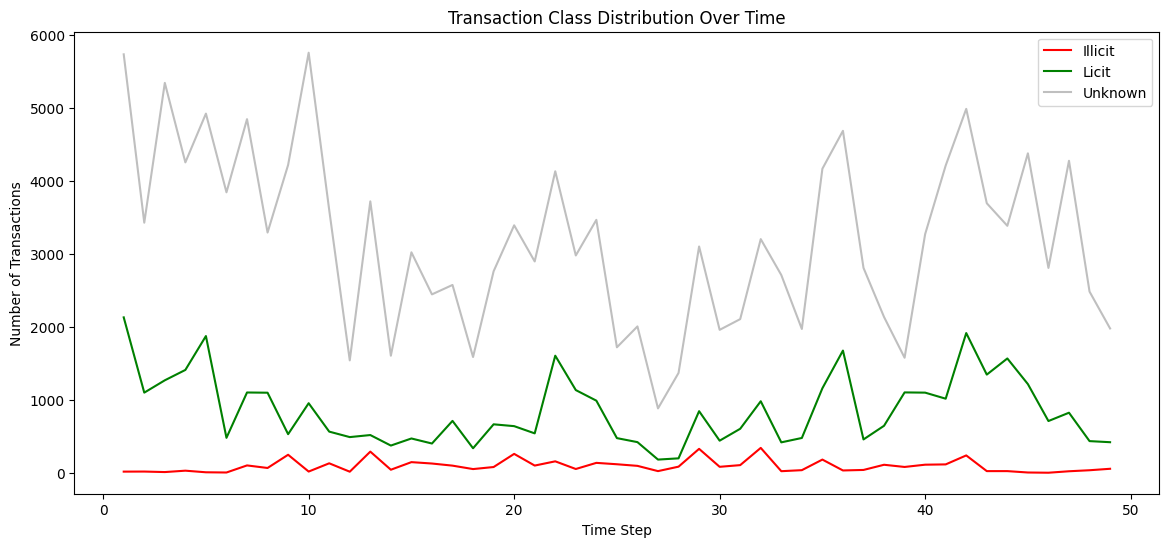

In [21]:
import matplotlib.pyplot as plt

# Count class distribution per time_step
time_class_counts = df.groupby(["time_step", "class"]).size().unstack(fill_value=0)

# Plot illicit vs licit over time
plt.figure(figsize=(14, 6))
plt.plot(time_class_counts.index, time_class_counts["1"], label="Illicit", color="red")
plt.plot(time_class_counts.index, time_class_counts["2"], label="Licit", color="green")
plt.plot(time_class_counts.index, time_class_counts["unknown"], label="Unknown", color="gray", alpha=0.5)
plt.xlabel("Time Step")
plt.ylabel("Number of Transactions")
plt.title("Transaction Class Distribution Over Time")
plt.legend()
plt.show()

In [23]:
illicit_df = df[df["class"] == "1"]

In [24]:
illicit_by_time = illicit_df.groupby("time_step").size()